# Fotogrametría: Reconstrucción 3D de objetos

In [1]:
import os
import random

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import pyvista as pv
import rembg

En esta etapa inicial, el objetivo es preparar las imágenes crudas para maximizar la calidad de la reconstrucción 3D. El flujo de trabajo consiste en:

1.  **Carga de Imágenes**: Lectura del dataset original.
2.  **Corrección Gamma**: Aplicamos una expansión de señal (gamma > 1.0) para realzar detalles en zonas de sombra sin saturar las luces. Esto ayuda a que el algoritmo de segmentación distinga mejor el objeto del fondo.
3.  **Eliminación de Fondo (Segmentation)**: Utilizamos `rembg` (basado en U2Net) para generar una máscara de transparencia (canal Alpha). Eliminar el fondo reduce el ruido y evita que se generen puntos 3D erróneos fuera del objeto de interés.
4.  **Guardado**: Las imágenes procesadas se guardan en formato PNG (con transparencia) para ser usadas en las siguientes etapas.

Este preprocesamiento es crítico para asegurar que los algoritmos de detección de características (SIFT) se concentren únicamente en la geometría del objeto.

## 1. Preprocesado

In [2]:
SAMPLES_DIR = 'Samples'
SAMPLE_BASE_PATH = os.path.join(SAMPLES_DIR, '09_Samples')
SAMPLE_STATE_00  = os.path.join(SAMPLE_BASE_PATH, '00_state')
IMAGES = []

print("Cargando imágenes...")
# Procesamos todas las imágenes encontradas en el directorio
for i in range(1, len(os.listdir(SAMPLE_STATE_00)) + 1):
    print(f"|-> Procesando imagen {i:02d} de {len(os.listdir(SAMPLE_STATE_00))}", end='\r')
    file_path = os.path.join(SAMPLE_STATE_00, f"{i:02d}_model.jpeg")

    IMAGES.append(cv.imread(file_path, cv.IMREAD_COLOR_RGB))
print("Imágenes cargadas correctamente.")

Cargando imágenes...
Imágenes cargadas correctamente.


## 1.1 Funciones de Preprocesado

Para automatizar el proceso, definimos dos funciones clave:

*   `apply_gamma(img, g)`: Aplica una transformación de potencia a los píxeles.
    *   Si $g > 1$, la imagen se oscurece, aumentando el contraste en las zonas medias.
    *   Si $g < 1$, la imagen se aclara.
    *   En nuestro caso, buscamos un valor que resalte los bordes del objeto frente al fondo.
*   `remove_background(img_rgba, session, gamma)`: Orquesta el proceso completo para una imagen:
    1.  Separa los canales RGB.
    2.  Aplica la corrección gamma temporalmente para mejorar la detección.
    3.  Pasa la imagen mejorada a `rembg` para obtener la máscara.
    4.  Aplica la máscara a la imagen **original** (sin gamma alterado) para preservar los colores reales de la textura.

In [3]:
def apply_gamma(img, gamma):
    img_f = img.astype(np.float32) / 255.0
    img_f = np.clip(np.power(img_f, gamma), 0.0, 1.0)
    return (img_f * 255).astype(np.uint8)

def remove_background(img, session, gamma=1.0):
    img_copy = img.copy()

    img_enhanced = apply_gamma(img_copy, gamma)
    mask = rembg.remove(img_enhanced, session=session, only_mask=True)
    
    rgba = np.dstack((img, mask))
    rgba[mask == 0] = 0
    return rgba

## 1.2 Experimentación

### 1.2.1: Benchmark de Gamma

No existe un valor de gamma universal; depende de la iluminación de la escena. Realizamos un test visual con tres valores:
*   **Gamma 1.0**: Imagen original.
*   **Gamma 1.5**: Contraste medio.
*   **Gamma 2.0**: Contraste alto (sombras más marcadas).

**Objetivo**: Buscamos el valor que produzca la máscara más limpia (bordes suaves, sin "mordiscos" al objeto y sin restos de fondo). Visualizamos los resultados lado a lado.

2025-12-09 22:29:52.103847693 [E:onnxruntime:Default, provider_bridge_ort.cc:2251 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1844 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library libonnxruntime_providers_cuda.so with error: libcublasLt.so.12: cannot open shared object file: No such file or directory



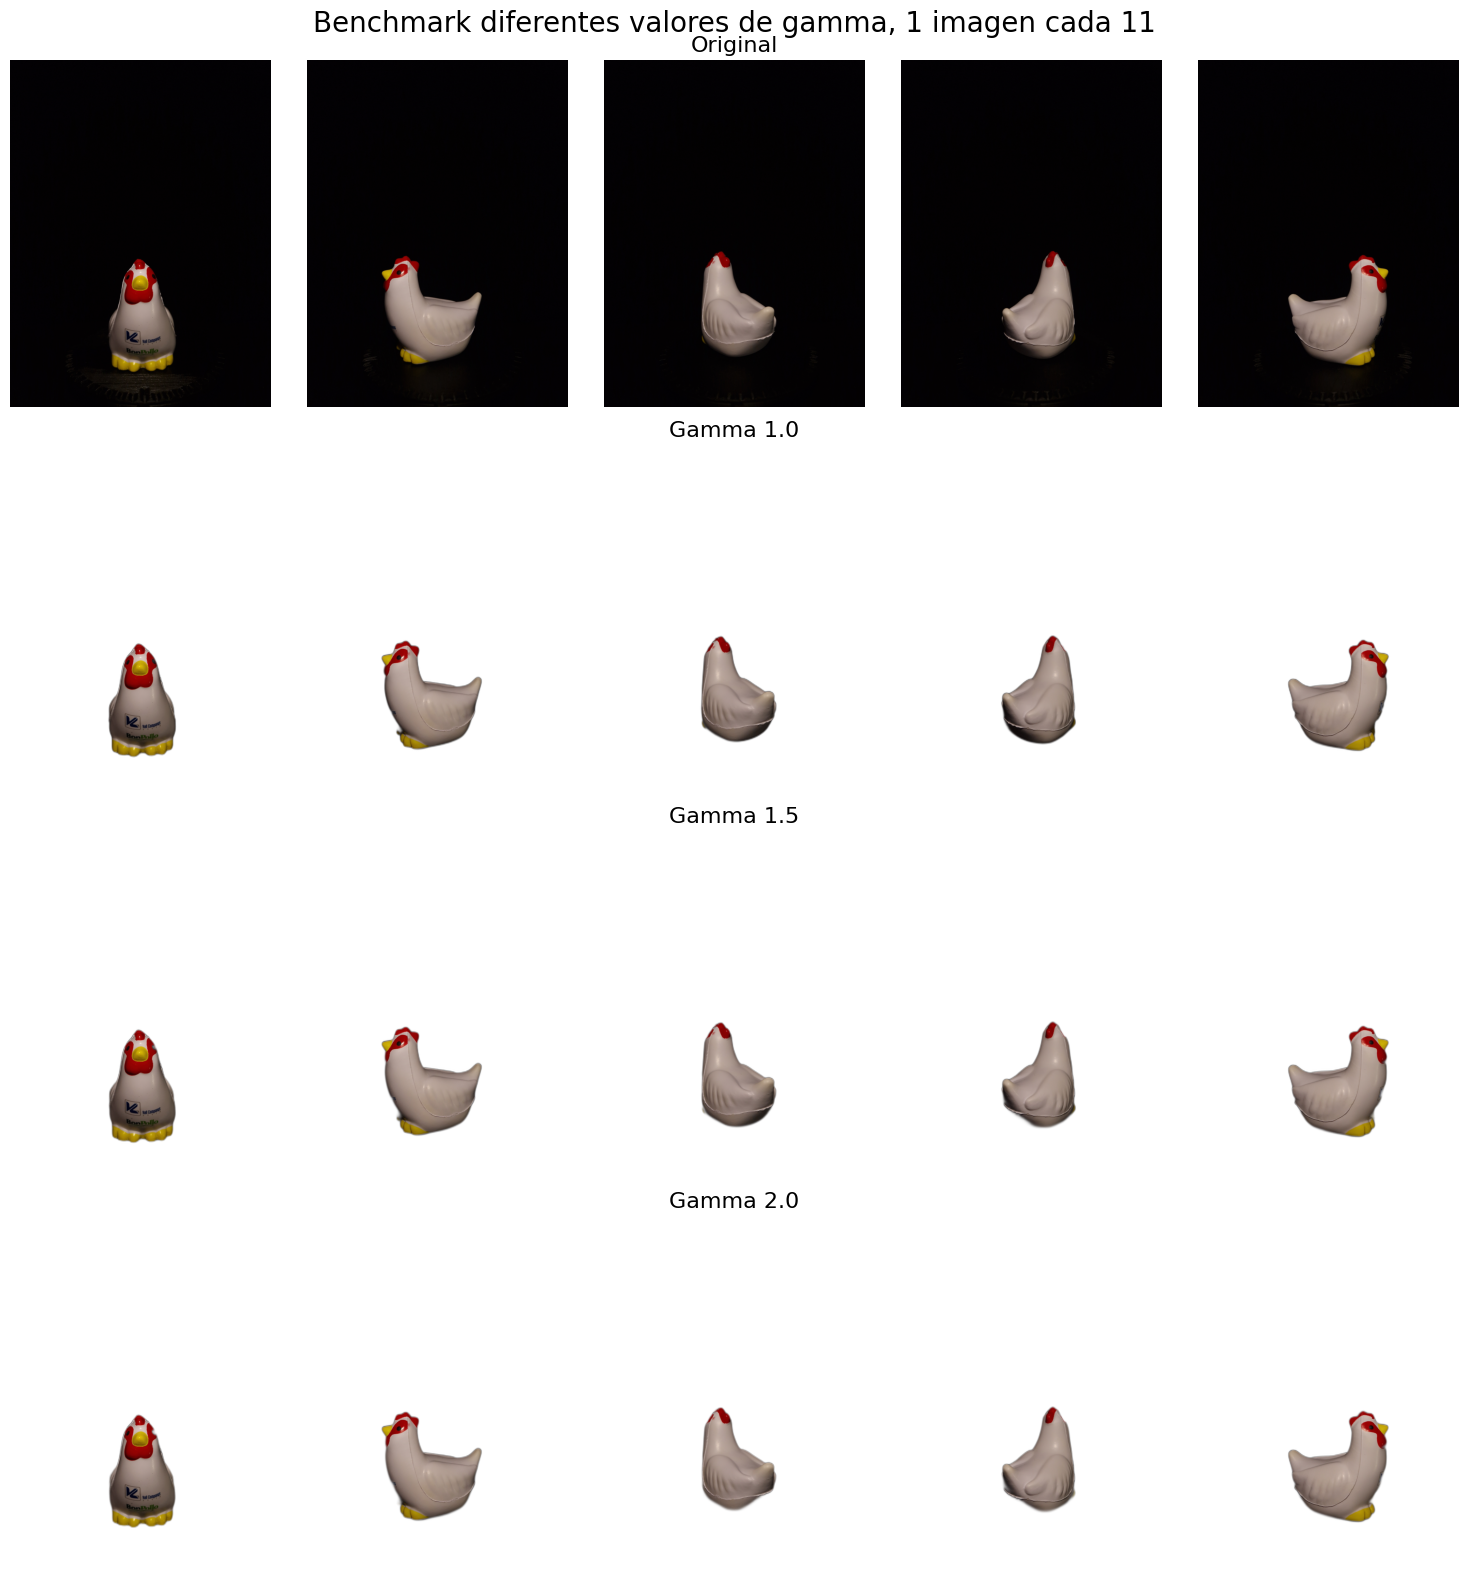

In [4]:
def benchmark_gamma(images, gammas): 
    default_rembg_session = rembg.new_session("u2net") 

    selected_images = images[0::11]

    rows = len(gammas) + 1 
    cols = len(selected_images)

    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 4 * rows)) 
    fig.suptitle("Benchmark diferentes valores de gamma, 1 imagen cada 11", fontsize=20)
    for i, img_rgb in enumerate(selected_images): 
        
        axes[0, i].imshow(img_rgb) 
        axes[0, i].axis('off') 
         
        if i == cols // 2: 
            axes[0, i].set_title("Original", fontsize=16) 

        for j, g in enumerate(gammas): 
            img_no_bg = remove_background(img_rgb, default_rembg_session, gamma=g) 
             
            axes[j+1, i].imshow(img_no_bg) 
            axes[j+1, i].axis('off') 
             
            if i == cols // 2: 
                axes[j+1, i].set_title(f"Gamma {g}", fontsize=16) 
    plt.tight_layout()
    plt.show() 

# Ejemplo de uso
gammas = [1.0, 1.5, 2.0] 
benchmark_gamma(IMAGES, gammas)

Como se puede observar, el mejor valor de gamma para este conjunto de imágenes es 1.5, ya que proporciona un buen equilibrio entre la eliminación del fondo y la preservación de los detalles del objeto.

In [5]:
GAMMA = 1.5

### 1.2.1 Selección de Modelo de Segmentación

La librería `rembg` permite utilizar diferentes modelos de redes neuronales para la segmentación (ej. `u2net`, `u2netp`, `isnet-general-use`, `sam`).

Aunque el modelo por defecto (`u2net`) ofrece un excelente equilibrio entre calidad y rendimiento para objetos generales, en casos donde el objeto tiene detalles muy finos (como cabello o mallas) o un contraste muy bajo con el fondo, sería recomendable realizar un segundo benchmark comparando estos modelos.

Para este proyecto, tras la evaluación visual del benchmark de gamma, determinamos que **`u2net` con Gamma=2.0** proporciona resultados satisfactorios, por lo que procedemos con esta configuración.

Iniciando benchmark de modelos con Gamma=1.5...


2025-12-09 22:30:17.704825348 [E:onnxruntime:Default, provider_bridge_ort.cc:2251 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1844 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library libonnxruntime_providers_cuda.so with error: libcublasLt.so.12: cannot open shared object file: No such file or directory

2025-12-09 22:30:17.885630136 [E:onnxruntime:Default, provider_bridge_ort.cc:2251 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1844 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library libonnxruntime_providers_cuda.so with error: libcublasLt.so.12: cannot open shared object file: No such file or directory




Benchmark finalizado.


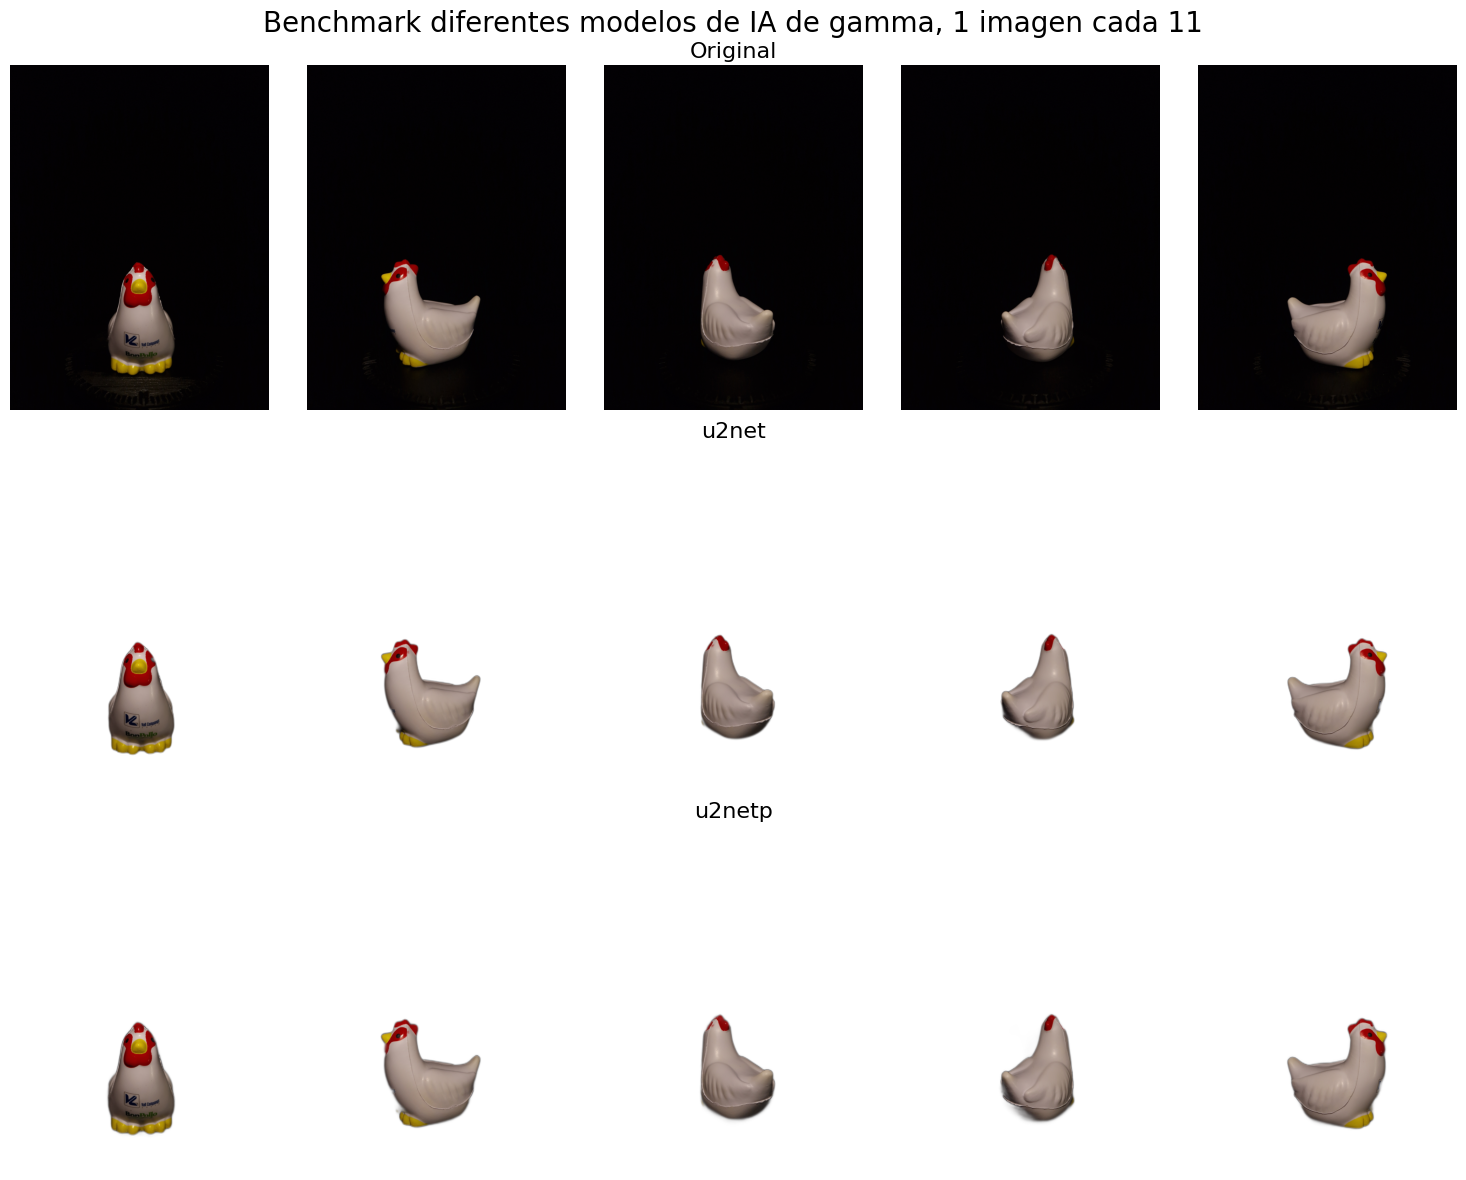

In [6]:
def benchmark_rembg_models(images, gamma):
    model_names = [
        "u2net", "u2netp", #"u2net_human_seg", "u2net_cloth_seg", 
        #"silueta", "isnet-general-use", "isnet-anime"
    ]
    print(f"Iniciando benchmark de modelos con Gamma={gamma}...")
    
    selected_images = images[0::11]
    # Pre-cargamos sesiones para evitar recrearlas en el bucle interno
    sessions = {name: rembg.new_session(name) for name in model_names}
    
    rows = len(model_names) + 1
    cols = len(selected_images)

    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 4 * rows)) 
    fig.suptitle("Benchmark diferentes modelos de IA de gamma, 1 imagen cada 11", fontsize=20)

    for i, img in enumerate(selected_images):
        # 1. Original
        axes[0, i].imshow(img)
        axes[0, i].axis('off')
        if i == len(selected_images) // 2:
            axes[0, i].set_title("Original", fontsize=16)

        # 2. Modelos
        for j, name in enumerate(model_names):
            # Usamos la sesión pre-cargada y nuestra función remove_background
            res = remove_background(img, sessions[name], gamma=gamma)
            
            axes[j+1, i].imshow(res)
            axes[j+1, i].axis('off')

            if i == len(selected_images) // 2:
                axes[j+1, i].set_title(name, fontsize=16)

    print("\nBenchmark finalizado.")
    plt.tight_layout()
    plt.show()

# Ejecución
benchmark_rembg_models(IMAGES, GAMMA)

In [7]:
REMBG_SESSION = rembg.new_session("u2net")

2025-12-09 22:30:35.605317144 [E:onnxruntime:Default, provider_bridge_ort.cc:2251 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1844 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library libonnxruntime_providers_cuda.so with error: libcublasLt.so.12: cannot open shared object file: No such file or directory



Como vemos en los resultados, el modelo "u2net" con un ajuste de gamma de 1.5 ofrece un equilibrio óptimo entre la precisión del recorte y la preservación de detalles importantes en las imágenes de nuestro objeto de interés.

## 1.3 Ejecución del Pipeline de Preprocesado

Con los parámetros definidos (**Gamma = 1.5**), ejecutamos el procesamiento por lotes para todo el dataset.

El script iterará sobre todas las imágenes cargadas:
1.  Aplicará la eliminación de fondo con la configuración óptima.
2.  Convertirá el resultado al espacio de color BGRA (requerido por OpenCV para guardar).
3.  Guardará los archivos `.png` resultantes en el directorio de salida (`01_state` o similar), listos para la extracción de características.

In [8]:
IMAGES_BGLESS = []
SAMPLE_STATE_01  = os.path.join(SAMPLE_BASE_PATH, '01_state')

print("Iniciando procesamiento...")
for i, img_rgba in enumerate(IMAGES):
    final_img = remove_background(img_rgba, REMBG_SESSION, gamma=GAMMA)
    IMAGES_BGLESS.append(final_img)
    
    filename = f"{i+1:02d}_model.png"
    out_path = os.path.join(SAMPLE_STATE_01, filename)
    cv.imwrite(out_path, final_img)
    # Usamos end='\r' para sobrescribir la línea y evitar imprimir una lista larga
    print(f"|-> Procesada imagen: {filename}", end='\r')

print("") # Salto de línea final
print('Procesamiento completado.')

Iniciando procesamiento...
|-> Procesada imagen: 55_model.png
Procesamiento completado.


# 2. Extracción y detección de características

## 2.1 Algoritmo SIFT (Scale-Invariant Feature Transform)

Para la reconstrucción 3D, es fundamental encontrar puntos correspondientes ("matches") entre pares de imágenes consecutivas. Para ello, utilizamos el algoritmo **SIFT**, un estándar en visión por computador valorado por su gran robustez.

**¿Por qué usamos SIFT?**
A diferencia de otros detectores de esquinas simples, SIFT es capaz de detectar y describir características locales ("keypoints") que son invariantes a:
*   **Escala**: Reconoce el mismo detalle aunque el objeto esté más cerca o más lejos en la foto.
*   **Rotación**: Funciona correctamente aunque la cámara o el objeto hayan girado.
*   **Iluminación**: Es parcialmente invariante a cambios de luz y ruido.

**El flujo de trabajo implementado es:**

1.  **Detección de Keypoints**: Identificamos puntos de interés distintivos en ambas imágenes.
2.  **Cálculo de Descriptores**: Para cada punto, SIFT genera una "huella digital" numérica (vector de 128 valores) que describe la textura y gradientes a su alrededor.
3.  **Matching (Emparejamiento)**: Comparamos los descriptores de la *Imagen A* con los de la *Imagen B*. Utilizamos `BFMatcher` (Brute Force) con `knnMatch` ($k=2$) para encontrar los **dos** mejores candidatos para cada punto.
4.  **Filtrado (Lowe's Ratio Test)**: Para descartar falsos positivos, aplicamos la "Prueba de Razón de Lowe". Solo aceptamos un emparejamiento si la distancia al *mejor* candidato es significativamente menor (por ejemplo, $< 0.7$) que la distancia al *segundo mejor*. Esto elimina ambigüedades y asegura que el match es único y confiable.

# TODO: Mejorar preprocesado previo a SIFT

In [9]:
def feature_and_matching(im1, im2):
    """
    Detecta características y realiza el emparejamiento ROBUSTO (Bidireccional) entre dos imágenes.
    Incluye mejora de contraste local (CLAHE) para zonas con poca textura.
    """

    gray1 = cv.cvtColor(im1, cv.COLOR_RGB2GRAY)
    gray2 = cv.cvtColor(im2, cv.COLOR_RGB2GRAY)

    # CLAHE: Realza texturas locales (útil para superficies lisas)
    # clipLimit=3.0 aumenta el contraste, tileGridSize=(8,8) es la ventana local
    clahe = cv.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    img1_enhanced = clahe.apply(gray1)
    img2_enhanced = clahe.apply(gray2)

    # --- DETECCIÓN SIFT ---
    # Bajamos contrastThreshold (0.04 -> 0.02) para detectar puntos más débiles
    # Esto genera más puntos, pero el matching bidireccional se encargará de filtrar el ruido.
    sift = cv.SIFT_create(contrastThreshold=0.02, edgeThreshold=10)

    kp1, des1 = sift.detectAndCompute(img1_enhanced, None)
    kp2, des2 = sift.detectAndCompute(img2_enhanced, None)

    if des1 is None or des2 is None:
        return np.array([]), np.array([]), (), (), []

    bf = cv.BFMatcher()
    
    # --- MATCHING BIDIRECCIONAL (Symmetry Test) ---
    # 1. Match 1 -> 2
    matches12 = bf.knnMatch(des1, des2, k=2)
    good12 = []
    ratio_threshold = 0.75 # Relajamos un poco el ratio (0.70 -> 0.75) al haber mejorado el contraste
    for m, n in matches12:
        if m.distance < n.distance * ratio_threshold:
            good12.append(m)

    # 2. Match 2 -> 1
    matches21 = bf.knnMatch(des2, des1, k=2)
    good21 = []
    for m, n in matches21:
        if m.distance < n.distance * ratio_threshold:
            good21.append(m)

    # 3. Intersección (Cross Check)
    # Solo aceptamos si queryIdx en 1->2 coincide con trainIdx en 2->1
    good_matches = []
    
    # Crear diccionario para búsqueda rápida de matches21: {queryIdx_en_2: trainIdx_en_1}
    matches21_dict = {m.queryIdx: m.trainIdx for m in good21}
    
    for m in good12:
        # m.trainIdx es el índice en kp2. Verificamos si ese punto en kp2 apunta de vuelta a m.queryIdx en kp1
        if m.trainIdx in matches21_dict and matches21_dict[m.trainIdx] == m.queryIdx:
            good_matches.append(m)

    pts1 = np.float32([kp1[p.queryIdx].pt for p in good_matches])
    pts2 = np.float32([kp2[p.trainIdx].pt for p in good_matches])

    return pts1, pts2, kp1, kp2, good_matches

## 2.2 Ejecución y Visualización del Matching

A continuación, probamos la función con dos imágenes consecutivas del dataset procesado. Visualizaremos las líneas que conectan los puntos clave encontrados en ambas imágenes para verificar visualmente la calidad de los emparejamientos. Si las líneas son paralelas y coherentes, el matching es correcto; si hay muchas líneas cruzadas caóticas, el filtrado necesita ajuste.

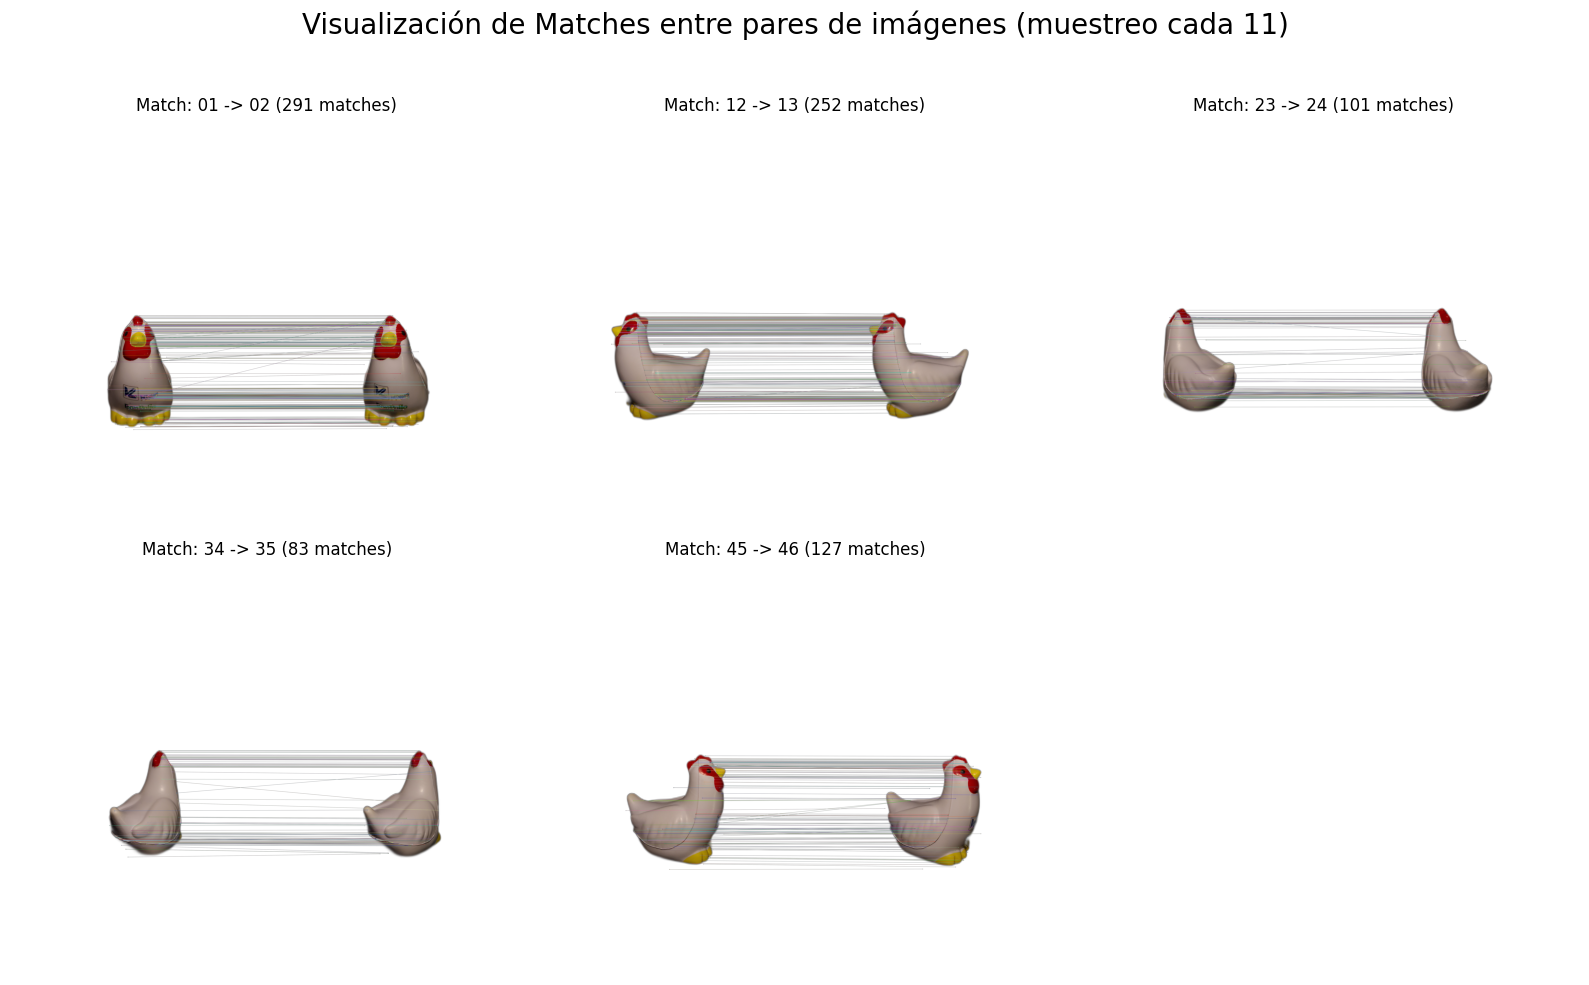

In [10]:
def visualize_matches(images):
    # Esto mostrará el matching entre la imagen i y i+1, para i = 0, 11, 22...
    pairs = [(i, i+1) for i in range(0, len(images), 11)]
    cols, rows = 3, 2
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
    fig.suptitle("Visualización de Matches entre pares de imágenes (muestreo cada 11)", fontsize=20)
    
    axes = axes.flatten()
    for idx, (idx1, idx2) in enumerate(pairs):
        img1, img2 = images[idx1], images[idx2]
        
        # Ejecutamos la función de matching
        pts1, pts2, kp1, kp2, matches = feature_and_matching(img1, img2)
        
        # Dibujamos los matches
        # Usamos flags=2 para dibujar solo los puntos coincidentes y líneas
        res = cv.drawMatches(img1, kp1, img2, kp2, matches, None, flags=2)
        
        axes[idx].imshow(res)
        axes[idx].set_title(f"Match: {idx1+1:02d} -> {idx2+1:02d} ({len(matches)} matches)")
        axes[idx].axis('off')

    axes[5].axis('off')

    plt.tight_layout()
    plt.show()

visualize_matches(IMAGES_BGLESS)

## Sfm: Structure from Motion

Buscamos la matriz fundamental utilizando RANSAC y validamos de la Geometría Epipolar para ver si el emparejamiento hecho anteriormente tienen verdaderamente relación geometrica

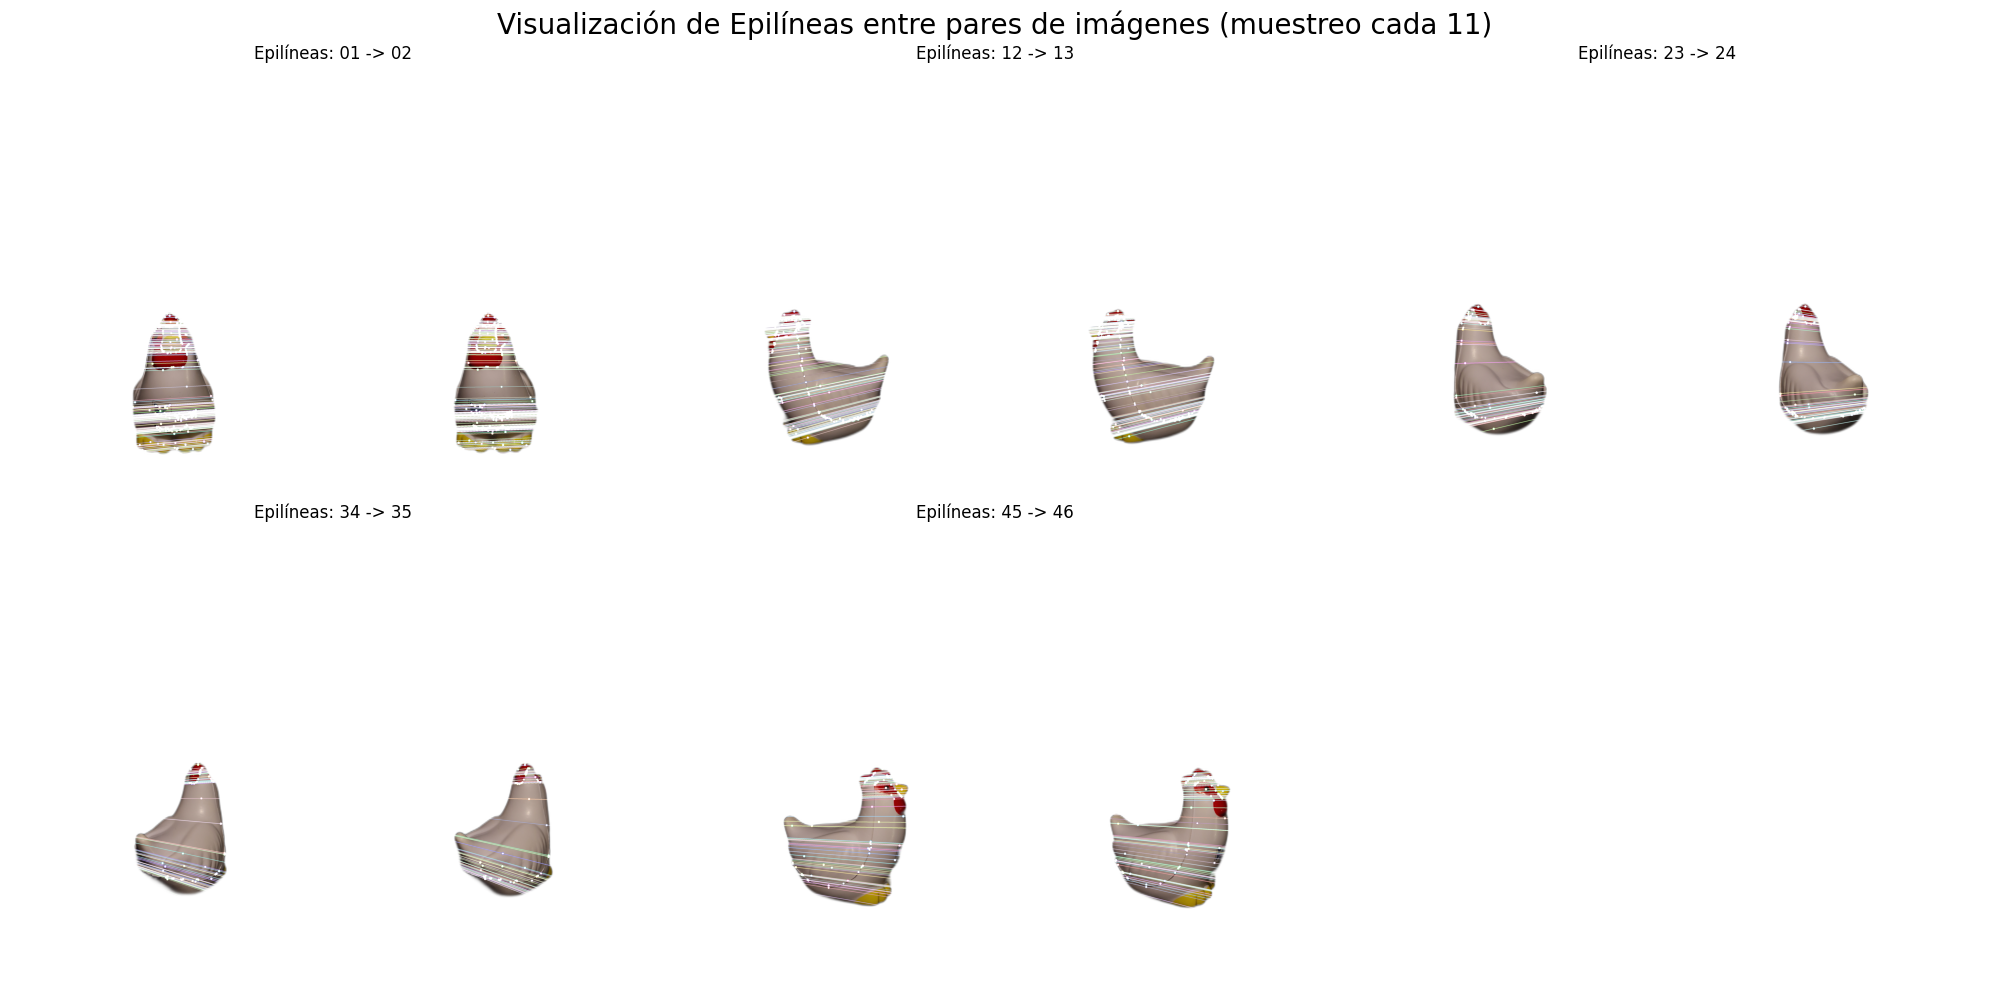

In [11]:
def visualize_epilines_all(images):
    # Seleccionamos pares representativos (cada 11 imágenes)
    pairs = [(i, i+1) for i in range(0, len(images), 11)]
    cols, rows = 3, 2

    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
    fig.suptitle("Visualización de Epilíneas entre pares de imágenes (muestreo cada 11)", fontsize=20)

    axes = axes.flatten()

    def dibujar_epilineas(img, lines, pts):
        h, w = img.shape[:2]
        out_img = img.copy()    
        for r, pt in zip(lines, pts):
            color = tuple(np.random.randint(0, 255, 3).tolist())
            a, b, c = r
            # Dibujar línea: ax + by + c = 0
            # Si b es muy pequeño, es una línea vertical aprox
            if abs(b) > 1e-5:
                y0 = int(-c/b)
                y1 = int(-(c + a*w)/b)
                cv.line(out_img, (0, y0), (w, y1), color, 2)
            else:
                x0 = int(-c/a)
                cv.line(out_img, (x0, 0), (x0, h), color, 2)
                
            # Dibujar el punto (debe caer sobre la línea)
            cv.circle(out_img, tuple(int(x) for x in pt), 10, color, -1)
        return out_img

    for idx, (idx1, idx2) in enumerate(pairs):
        img1, img2 = images[idx1], images[idx2]
        
        # Ejecutamos la función de matching
        pts1, pts2, kp1, kp2, matches = feature_and_matching(img1, img2)

        if len(pts1) < 8:
             print(f"No hay suficientes puntos para el par {idx1}->{idx2}")
             continue

        # 1. Calculamos F y seleccionamos una muestra aleatoria
        F, mask = cv.findFundamentalMat(pts1, pts2, cv.FM_RANSAC)
        
        if F is None:
             print(f"No se pudo calcular F para el par {idx1}->{idx2}")
             continue
        

        # Seleccionamos solo los inliers para que la visualización sea correcta
        mask = mask.ravel() == 1
        pts1_inliers, pts2_inliers = pts1[mask], pts2[mask]
        
        if len(pts1_inliers) < 1:
             print(f"No hay inliers para el par {idx1}->{idx2}")
             continue
        # 2. Cálculo de líneas recíprocas
        # Líneas en Img1 (correspondientes a puntos de Img2) -> whichImage=2
        lines1 = cv.computeCorrespondEpilines(pts2_inliers.reshape(-1, 1, 2), 2, F).reshape(-1, 3)
        # Líneas en Img2 (correspondientes a puntos de Img1) -> whichImage=1
        lines2 = cv.computeCorrespondEpilines(pts1_inliers.reshape(-1, 1, 2), 1, F).reshape(-1, 3)

        # 4. Visualización Recíproca
        img1_epilines = dibujar_epilineas(img1, lines1, pts1_inliers) # Puntos en Img1 vs Líneas de Img2
        img2_epilines = dibujar_epilineas(img2, lines2, pts2_inliers) # Puntos en Img2 vs Líneas de Img1

        # Mostrar lado a lado
        final_concat = np.hstack((img1_epilines, img2_epilines))
        
        ax = axes[idx]
        ax.imshow(final_concat)
        ax.set_title(f"Epilíneas: {idx1+1:02d} -> {idx2+1:02d}")
        ax.axis('off')

    axes[5].axis('off')

    plt.tight_layout()
    plt.show()

visualize_epilines_all(IMAGES_BGLESS)

Funcion donde se tiangula las posiciones de los puntos de 2 imagenes para calcular las posiciones 3D de dichas imagenes.

In [13]:
def Sfm_circular(im1, im2, K, idx1, idx2, n_imgs, rad, direction=1):
    """
    Realiza la reconstrucción 3D asumiendo una trayectoria circular perfecta (Turntable).
    Calcula las poses absolutas de las cámaras basándose en sus índices.
    
    Args:
        im1, im2: Imágenes.
        K: Matriz intrínseca.
        idx1, idx2: Índices de las imágenes en la secuencia (0..N-1).
        n_imgs: Número total de imágenes.
        rad: Radio de la órbita (distancia de la cámara al centro del objeto).
        direction: 1 o -1. Invierte el sentido de la rotación.
    """
    
    # 1. Obtener Puntos Emparejados
    pts1, pts2, kp1, kp2, good_matches = feature_and_matching(im1, im2)

    # Necesitamos al menos 8 puntos para calcular F de forma robusta
    if len(pts1) < 8:
        return np.zeros((0, 3))
    
    pts1 = np.ascontiguousarray(pts1)
    pts2 = np.ascontiguousarray(pts2)

    # --- FILTRADO DE OUTLIERS (NUEVO) ---
    # Usamos RANSAC para encontrar la Matriz Fundamental y descartar matches erróneos
    # que no cumplen la geometría epipolar, antes de forzar la triangulación.
    # threshold=1.0 píxel de error máximo para considerar inlier
    F, mask = cv.findFundamentalMat(pts1, pts2, cv.FM_RANSAC, 1.0, 0.99)
    
    if F is None:
        return np.zeros((0, 3))
        
    # Aplicamos la máscara para quedarnos solo con los inliers
    mask = mask.ravel() == 1
    pts1 = pts1[mask]
    pts2 = pts2[mask]
    
    if len(pts1) < 5:
        return np.zeros((0, 3))
    # ------------------------------------

    # 2. Calcular Poses Absolutas
    def get_pose(idx, N, R_dist, rot_dir):
        # Ángulo de rotación
        theta = rot_dir * idx * (2 * np.pi / N)
        
        # Rotación alrededor del eje Y
        c, s = np.cos(theta), np.sin(theta)
        R = np.array([
            [c, 0, s],
            [0, 1, 0],
            [-s, 0, c]
        ])
        
        # Traslación: Objeto centrado en (0,0,R_dist) frente a la cámara
        t = np.array([[0], [0], [R_dist]])
        
        return R, t

    R1, t1 = get_pose(idx1, n_imgs, rad, direction)
    R2, t2 = get_pose(idx2, n_imgs, rad, direction)

    # Matrices de Proyección
    P1 = K @ np.hstack((R1, t1))
    P2 = K @ np.hstack((R2, t2))
    
    # 3. Triangulación 3D
    pts4d = cv.triangulatePoints(P1, P2, pts1.T, pts2.T)
    
    # Normalización homogénea
    # Evitar división por cero
    w_coord = pts4d[3]
    w_coord[np.abs(w_coord) < 1e-5] = 1e-5
    
    pts3d = pts4d[:3] / w_coord
    
    # CORRECCIÓN DE EJES
    # Invertimos el eje Y (Vertical) porque OpenCV usa Y-down y el usuario reporta inversión
    pts3d[1] *= -1

    return pts3d.T.copy()

In [14]:
P_LOW = 0   # Percentil inferior para filtrado
P_HIGH = 99  # Percentil superior para filtrado

h, w = IMAGES_BGLESS[0].shape[:2]
# Matriz K calibrada (proporcionada)
K = np.array([
    [2.69889306e+03, 0.00000000e+00, 1.49789941e+03],
    [0.00000000e+00, 2.76369335e+03, 2.04250158e+03],
    [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]
])

# Coeficientes de distorsión (proporcionados)
# k1, k2, p1, p2, k3
dist_coeffs = np.array([0.15055201, -0.79565235, 0.00639867, -0.00277334, 1.94243501])



print("Aplicando corrección de distorsión a las imágenes...")
h, w = IMAGES_BGLESS[0].shape[:2]
    
# Obtener la nueva matriz óptima de cámara (alpha=1 para no perder píxeles)
# Esto ajusta K para tener en cuenta el "estiramiento" de la imagen
newcameramtx, roi = cv.getOptimalNewCameraMatrix(K, dist_coeffs, (w,h), 1, (w,h))
    
IMAGES_UNDISTORTED = []
for img in IMAGES_BGLESS:
    dst = cv.undistort(img, K, dist_coeffs, None, newcameramtx)
    IMAGES_UNDISTORTED.append(dst)
    
IMAGES_BGLESS = IMAGES_UNDISTORTED
K = newcameramtx # Actualizamos K para la reconstrucción
print("Imágenes corregidas y Matriz K actualizada.")

Aplicando corrección de distorsión a las imágenes...
Imágenes corregidas y Matriz K actualizada.


In [ ]:
from scipy.spatial import cKDTree

def clean_pcd_statistical(points, nb_neighbors=20, std_ratio=2.0):
    """
    Elimina outliers estadísticos (Statistical Outlier Removal).
    Para cada punto, calcula la distancia media a sus N vecinos.
    Si esa distancia es mayor que la media global + std_ratio * desviación, se descarta.
    """
    if len(points) < nb_neighbors:
        return points

    tree = cKDTree(points)
    # dists: distancias a los k vecinos más cercanos
    dists, _ = tree.query(points, k=nb_neighbors + 1) # +1 porque el primero es él mismo (dist 0)
    
    # Promedio de distancias (ignorando la primera columna que es 0)
    mean_dists = np.mean(dists[:, 1:], axis=1)
    
    global_mean = np.mean(mean_dists)
    global_std = np.std(mean_dists)
    
    threshold = global_mean + std_ratio * global_std
    
    mask = mean_dists < threshold
    return points[mask]

def procesar_reconstruccion_sfm(images, K, p_low=10, p_high=90):
    """
    Ejecuta el pipeline completo de Structure from Motion (SfM) para una secuencia de imágenes circular.
    """
    print(f"--- INICIO DE RECONSTRUCCIÓN SFM (CIRCULAR) ---")
    
    puntos_3d = np.zeros((0, 3))
    n_imgs = len(images)
    
    # Radio estimado (distancia al objeto). 
    # DIRECCIÓN DE ROTACIÓN:-1: Horario (o cámara antihoraria)
    RADIO = 2.0 
    DIRECTION = -1 
    
    for i in range(n_imgs):
        idx1 = i
        idx2 = (i + 1) % n_imgs
        
        img1 = images[idx1]
        img2 = images[idx2]
        
        # Usamos la nueva función con poses absolutas y dirección
        puntos = Sfm_circular(img1, img2, K, idx1, idx2, n_imgs, rad=RADIO, direction=DIRECTION)
        
        puntos_3d = np.vstack((puntos_3d, puntos))
            
        print(f"|-> Procesado par {idx1}-{idx2}: +{len(puntos)} puntos.", end='\r')
    
    print(f"\nTotal puntos generados (bruto): {len(puntos_3d)}")

    print(f"--- FILTRADO DE PUNTOS ---")

    mascara_validos = np.isfinite(puntos_3d).any(axis=1)
    puntos_limpios = puntos_3d[mascara_validos]
    print(f"Puntos tras eliminar Inf/NaN: {len(puntos_limpios)}")

    # 1. Filtrado Estadístico (SOR) - NUEVO
    # Elimina puntos aislados (ruido flotante)
    print("Aplicando Statistical Outlier Removal (SOR)...")
    puntos_sor = clean_pcd_statistical(puntos_limpios, nb_neighbors=50, std_ratio=1.0)
    print(f"Puntos tras SOR: {len(puntos_sor)} (Eliminados: {len(puntos_limpios) - len(puntos_sor)})")

    # 2. Filtrado de Caja (Percentiles)
    # Elimina puntos muy lejanos que hayan sobrevivido al SOR
    min_x, max_x = np.percentile(puntos_sor[:, 0], [p_low, p_high])
    min_y, max_y = np.percentile(puntos_sor[:, 1], [p_low, p_high])
    min_z, max_z = np.percentile(puntos_sor[:, 2], [p_low, p_high])

    filtro_percentil = (
        (puntos_sor[:, 0] > min_x) & (puntos_sor[:, 0] < max_x) &
        (puntos_sor[:, 1] > min_y) & (puntos_sor[:, 1] < max_y) &
        (puntos_sor[:, 2] > min_z) & (puntos_sor[:, 2] < max_z) 
    )

    puntos_finales = puntos_sor[filtro_percentil]
        
    print(f"Rango Z final: {puntos_finales[:, 2].min():.2f} a {puntos_finales[:, 2].max():.2f}")
    print(f"Puntos finales: {len(puntos_finales)}")

    print(f"---------------------------------------------------")
    return puntos_finales

# TODO: Aquí pasa algo raro y no no se el que

In [16]:
# 1. Ejecutar el procesamiento
puntos_finales = procesar_reconstruccion_sfm(IMAGES, K, p_low=P_LOW, p_high=P_HIGH)

# 2. Visualización
fig = go.Figure(data=[go.Scatter3d(
    x=puntos_finales[:,0],
    y=puntos_finales[:,1],
    z=puntos_finales[:,2],
    mode='markers',
    marker=dict(
        size=3,
        color=puntos_finales[:,2], # Colorear por profundidad (Z)
        colorscale='Hot',
        opacity=0.8
    )
)])

fig.update_layout(
    title=f"Nube de Puntos 3D ({len(puntos_finales)} puntos)",
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    margin=dict(l=0, r=0, b=0, t=30)
)

fig.show()
print(puntos_finales)

--- INICIO DE RECONSTRUCCIÓN SFM (CIRCULAR) ---
|-> Procesado par 54-0: +101 puntos..
Total puntos generados (bruto): 5184
--- FILTRADO DE PUNTOS ---
Puntos tras eliminar Inf/NaN: 5184
Aplicando Statistical Outlier Removal (SOR)...
Puntos tras SOR: 5079 (Eliminados: 105)
Rango Z final: -0.58 a 0.80
Puntos finales: 4923
---------------------------------------------------


[[-0.27143997 -0.77701592  0.12478729]
 [-0.22358759 -1.16755307  0.33832139]
 [-0.15822253 -0.60517734  0.56316739]
 ...
 [ 0.22000863 -1.02558982  0.66197485]
 [ 0.22242665 -1.00448334  0.67194611]
 [ 0.2233752  -1.03396118  0.64513248]]


In [ ]:
cloud = pv.PolyData(puntos_finales)
##--- 3. GENERAR LA MALLA (Meshing) ---
##Dado que son puntos dispersos, tenemos dos opciones principales:
mesh = cloud.delaunay_3d(alpha=0).extract_surface()

#--- 4. TEXTURIZADO Y MAPEO UV ---
##Si es algo esférico/cilíndrico/orgánico: Mapeo Esférico
mesh.texture_map_to_sphere(inplace=True)

##Si es algo plano (como un terreno o una cara vista de frente): Mapeo Plano
mesh.texture_map_to_plane(inplace=True) 

#Cargar una textura de prueba (PyVista trae algunas, o usa pv.read_texture('tu_foto.jpg'))
tex = pv.examples.download_masonry_texture()
#Para usar tu propia imagen descomenta abajo:

#--- 5. VISUALIZACIÓN ---
plotter = pv.Plotter()
plotter.add_mesh(mesh, cmap="viridis", show_edges=True) # show_edges ayuda a ver la geometría creada
plotter.add_points(cloud, color="red", point_size=10, render_points_as_spheres=True) # Ver puntos originales
plotter.show()

Widget(value='<iframe src="http://localhost:41771/index.html?ui=P_0x7f70c1dab390_7&reconnect=auto" class="pyvi…